<a href="https://colab.research.google.com/github/E23026/Statistical-Learning-e23026/blob/main/assignments/Kalman_filter_assignment_answers_E23026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

# **Answers - Q. Analytical Derivation**
### 1. Derivation of
  $x_k^- \sim \mathscr{N}(m_k^- P_k^-)$

Given the state equation: $x_k^- = A_{k-1}x^+_{k-1} + G_{k-1}w_{k-1}$, where $x^+_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$ and $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$.

**Mean:**
Using the linearity of expectation:
$$m_k^- = \mathbb{E}[x_k^-] = \mathbb{E}[A_{k-1}x^+_{k-1} + G_{k-1}w_{k-1}] = A_{k-1}\mathbb{E}[x^+_{k-1}] + G_{k-1}\mathbb{E}[w_{k-1}]$$
Since $\mathbb{E}[w_{k-1}] = 0$, we get:
$$m_k^- = A_{k-1}m_{k-1}$$

**Covariance:**
Assuming independence between the state and noise:
$$P_k^- = \text{Var}(x_k^-) = \text{Var}(A_{k-1}x^+_{k-1}) + \text{Var}(G_{k-1}w_{k-1})$$
$$P_k^- = A_{k-1}\text{Var}(x^+_{k-1})A_{k-1}^T + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^T$$
$$P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$

### 2. Derivation of $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$

Given $y_k^- = H_k x_k^- + z_k$ where $z_k \sim \mathscr{N}(0, \Sigma_m)$.

**Mean:**
$$\mathbb{E}[y_k^-] = \mathbb{E}[H_k x_k^- + z_k] = H_k \mathbb{E}[x_k^-] + 0 = H_k m_k^-$$

**Covariance:**
$$P_y = \text{Var}(y_k^-) = \text{Var}(H_k x_k^-) + \text{Var}(z_k) = H_k P_k^- H_k^T + \Sigma_m$$

### 3. Joint Distribution of $x_k^-$ and $y_k^-$

The joint vector is a linear transformation of the Gaussian variables $(x_k^-, z_k)$:
$$\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} = \begin{bmatrix} I \\ H_k \end{bmatrix} x_k^- + \begin{bmatrix} 0 \\ I \end{bmatrix} z_k$$

The cross-covariance is:
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(H_k(x_k^- - m_k^-) + z_k)^T] = P_k^- H_k^T$$
Thus,
$$\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} \sim \mathscr{N}\left( \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}, \begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix} \right)$$

### 4. Updated State $x_k^+$ (Kalman Update)

Using the property of conditional Gaussian distributions: If $\begin{bmatrix} a \\ b \end{bmatrix} \sim \mathscr{N}\left(\begin{bmatrix} \mu_a \\ \mu_b \end{bmatrix}, \begin{bmatrix} \Sigma_{aa} & \Sigma_{ab} \\ \Sigma_{ba} & \Sigma_{bb} \end{bmatrix}\right)$, then $a|b \sim \mathscr{N}(\mu_a + \Sigma_{ab}\Sigma_{bb}^{-1}(b - \mu_b), \Sigma_{aa} - \Sigma_{ab}\Sigma_{bb}^{-1}\Sigma_{ba})$.

Substituting $a=x_k^-$ and $b=y_k^-$:
$$K_k = \Sigma_{ab}\Sigma_{bb}^{-1} = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$
$$m_k = m_k^- + K_k (y_k^{\text{obs}} - H_k m_k^-)$$
$$P_k = P_k^- - K_k (H_k P_k^-) = (I - K_k H_k) P_k^-$$

### 5. Final Estimates

By definition of the posterior distribution derived in step 4:
$$\mathbb{E}[x_k^- \mid y_k^- = y_k^{\text{obs}}] = m_k$$
$$\text{Var}(x_k^- \mid y_k^- = y_k^{\text{obs}}) = P_k$$

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

# **Answers - Q. 1-D Example**

#### 1. Prediction Step
Given $x^-_k = a x^+_{k-1} + w_{k-1}$ with $w_{k-1} \sim \mathscr{N}(0, q)$:
- **Mean**: $m_k^- = \mathbb{E}[a x^+_{k-1} + w_{k-1}] = a \mathbb{E}[x^+_{k-1}] + 0 = a m_{k-1}$.
- **Covariance**: $P_k^- = \text{Var}(a x^+_{k-1} + w_{k-1}) = a^2 \text{Var}(x^+_{k-1}) + \text{Var}(w_{k-1}) = a^2 P_{k-1} + q$.

#### 2. Update Step (Filtering)
Using the scalar version of the Kalman gain $K_k = \frac{P_k^- h}{h^2 P_k^- + r}$:
- **Mean**: $m_k = m_k^- + K_k(y^{\text{obs}}_k - h m_k^-)$. Substituting $K_k$ gives the requested form.
- **Covariance**: $P_k = (1 - K_k h)P_k^-$. Substituting $K_k$:
  $P_k = (1 - \frac{P_k^- h^2}{S_k}) P_k^-$.

#### 3. Predictive Measurement Distribution
$y^-_k = h x^-_k + z_k$. Since $x^-_k | Y_{k-1} \sim \mathscr{N}(m_k^-, P_k^-)$ and $z_k \sim \mathscr{N}(0, r)$:
- $\mathbb{E}[y^-_k | Y_{k-1}] = h m_k^-$.
- $\text{Var}(y^-_k | Y_{k-1}) = h^2 P_k^- + r$.
- Thus, $p(y^-_k | Y_{k-1}) = \mathscr{N}(h m_k^-, h^2 P_k^- + r)$.

#### 4. Posterior-Predictive Measurement Distribution
After observing $y_k$ and updating the state to $x_k | Y_k \sim \mathscr{N}(m_k, P_k)$:
- $\mathbb{E}[y^-_k | Y_k] = h m_k$.
- $\text{Var}(y^-_k | Y_k) = h^2 P_k + r$.
- Thus, $p(y^-_k | Y_k) = \mathscr{N}(h m_k, h^2 P_k + r)$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from IPython.display import HTML

# Parameters
a, q, h, r = 1.0, 0.5, 1.0, 1.0
m, p = 0.0, 2.0  # Initial prior

# Simulate data
np.random.seed(42)
true_x = 0
steps = 20
measurements = []
for _ in range(steps):
    true_x = a * true_x + np.random.normal(0, np.sqrt(q))
    measurements.append(h * true_x + np.random.normal(0, np.sqrt(r)))

fig, ax = plt.subplots(figsize=(10, 6))
x_axis = np.linspace(-10, 10, 500)
line_prior, = ax.plot([], [], 'r-', label='Prior $p(x_k | Y_{k-1})$')
line_post, = ax.plot([], [], 'b-', label='Posterior $p(x_k | Y_k)$')
meas_dot = ax.scatter([], [], c='black', label='Measurement $y_k$')

def init():
    ax.set_xlim(-10, 10)
    ax.set_ylim(0, 1.0)
    ax.legend()
    return line_prior, line_post, meas_dot

states = []
curr_m, curr_p = m, p

for y in measurements:
    # Predict
    m_minus = a * curr_m
    p_minus = a**2 * curr_p + q
    # Update
    S = h**2 * p_minus + r
    K = (p_minus * h) / S
    curr_m = m_minus + K * (y - h * m_minus)
    curr_p = (1 - K * h) * p_minus
    states.append((m_minus, p_minus, curr_m, curr_p, y))

def update(frame):
    m_m, p_m, m_p, p_p, y = states[frame]
    line_prior.set_data(x_axis, norm.pdf(x_axis, m_m, np.sqrt(p_m)))
    line_post.set_data(x_axis, norm.pdf(x_axis, m_p, np.sqrt(p_p)))
    meas_dot.set_offsets([[y, 0]])
    ax.set_title(f'Step {frame+1}: Filtering Observation {y:.2f}')
    return line_prior, line_post, meas_dot

ani = FuncAnimation(fig, update, frames=len(states), init_func=init, blit=True)
plt.close()
HTML(ani.to_jshtml())

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

### **Answers - Q. 2D-Position Estimation (Part A)**

#### Derivation of A
In a constant-velocity model, the position at time $k$ is the position at $k-1$ plus the distance traveled (velocity $\times \Delta t$). The velocity is assumed to remain constant ($v_k = v_{k-1}$).
- $p_x(k) = p_x(k-1) + v_x(k-1)\Delta t$
- $p_y(k) = p_y(k-1) + v_y(k-1)\Delta t$
- $v_x(k) = v_x(k-1)$
- $v_y(k) = v_y(k-1)$

Writing this in matrix form $x_k = A x_{k-1}$ gives:
$$\begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix} = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} p_x(k-1) \\ p_y(k-1) \\ v_x(k-1) \\ v_y(k-1) \end{bmatrix}$$

#### Derivation of H
The measurement $y_k$ contains only the position components $(p_x, p_y)$. Thus, $H$ must extract the first two elements of the state vector:
$$y_k = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix} \begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix}$$

#### Derivation of G
If we assume a random acceleration $a_k = [a_x, a_y]^T$ acts as the process noise, then by kinematic equations:
- $\Delta p = \frac{1}{2}a \Delta t^2$
- $\Delta v = a \Delta t$

Mapping the 2D noise vector $w_k = [a_x, a_y]^T$ to the 4D state vector:
$$x_k = A x_{k-1} + \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix} \begin{bmatrix} a_x \\ a_y \end{bmatrix}$$
This confirms the structure of $G$.

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

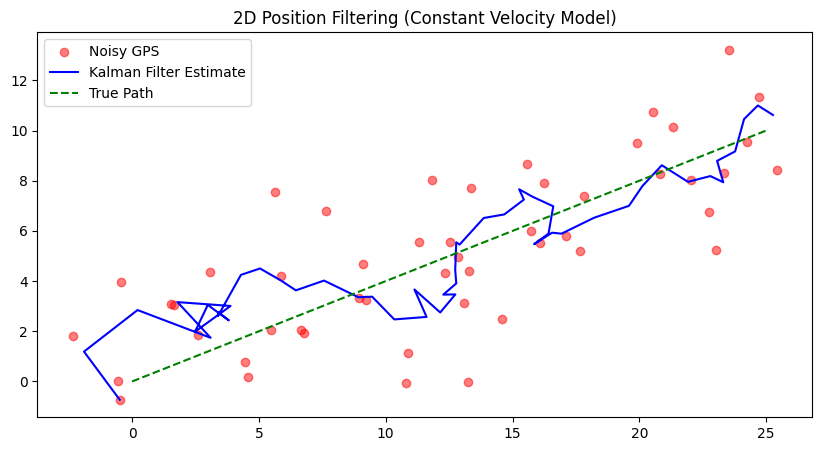

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def kalman_filter_2d(measurements, dt=1.0, sigma_p=0.1, sigma_m=2.0):
    # Initialize Matrices
    A = np.array([[1, 0, dt, 0], [0, 1, 0, dt], [0, 0, 1, 0], [0, 0, 0, 1]])
    H = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])
    G = np.array([[0.5*dt**2, 0], [0, 0.5*dt**2], [dt, 0], [0, dt]])

    Q = G @ (sigma_p**2 * np.eye(2)) @ G.T
    R = sigma_m**2 * np.eye(2)

    # Initial State
    m = np.array([measurements[0,0], measurements[1,0], 0, 0])
    P = np.eye(4) * 10

    filtered_states = []

    for i in range(measurements.shape[1]):
        # Prediction
        m = A @ m
        P = A @ P @ A.T + Q

        # Update
        y_obs = measurements[:, i]
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)
        m = m + K @ (y_obs - H @ m)
        P = (np.eye(4) - K @ H) @ P

        filtered_states.append(m)

    return np.array(filtered_states)

# Generate simulated GPS data
t = np.linspace(0, 50, 50)
true_pos = np.vstack([0.5 * t, 0.2 * t])
noisy_gps = true_pos + np.random.normal(0, 2.0, true_pos.shape)

# Apply filter
estimates = kalman_filter_2d(noisy_gps)

# Plotting
plt.figure(figsize=(10, 5))
plt.scatter(noisy_gps[0], noisy_gps[1], alpha=0.5, label='Noisy GPS', color='red')
plt.plot(estimates[:, 0], estimates[:, 1], 'b-', label='Kalman Filter Estimate')
plt.plot(true_pos[0], true_pos[1], 'g--', label='True Path')
plt.legend()
plt.title('2D Position Filtering (Constant Velocity Model)')
plt.show()